# Mini Pilot追試：固定Actor・Cost Critic単独学習

`mini_pilot_episodic_dcost6_mps` の最終checkpointを流用し、方策を完全固定したままCost Criticだけを追加学習します。

- 主試験: 固定Actorで新規収集したfresh Replay
- 補助試験: Mini Pilotに保存されたold Replay（既定ではOFF）
- Actor / Reward Critic / Reward target / entropy alpha / lambdaは変更禁止
- Cost targetはCost Criticに追従してsoft update
- Calibration corpusは最初に一度だけ生成し、全milestoneで同じ `(s, a, MC return)` を使用

元のMini Pilot成果物は読み取り専用で、結果は別フォルダへ保存します。

In [1]:
from pathlib import Path
from copy import deepcopy
import hashlib, json, platform
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display, HTML

ROOT = Path.cwd().resolve()
if not (ROOT / 'uav_safe_marl').is_dir():
    ROOT = ROOT.parent
SOURCE_RUN = ROOT / 'runs' / 'mini_pilot_episodic_dcost6_mps'
OUTPUT_RUN = ROOT / 'runs' / 'mini_pilot_cost_critic_followup'
FINAL_CHECKPOINT = SOURCE_RUN / 'checkpoints' / 'final.pt'
TRAINING_BANK_PATH = SOURCE_RUN / 'training_bank.json'
CALIBRATION_BANK_PATH = SOURCE_RUN / 'calibration_bank.json'

FRESH_EPISODES = 30
CALIBRATION_REPEATS = 3
UPDATE_MILESTONES = [0, 1_000, 5_000, 10_000, 20_000]
RUN_FRESH_REPLAY = True
RUN_OLD_REPLAY = False  # 補助比較。主試験終了後にTrueへ変更してよい
REBUILD_CALIBRATION_CORPUS = False
RECOLLECT_FRESH_REPLAY = False

for required in (FINAL_CHECKPOINT, TRAINING_BANK_PATH, CALIBRATION_BANK_PATH, SOURCE_RUN / 'resolved_config.json'):
    if not required.exists():
        raise FileNotFoundError(required)
OUTPUT_RUN.mkdir(parents=True, exist_ok=True)
CHECKPOINT_SHA256 = hashlib.sha256(FINAL_CHECKPOINT.read_bytes()).hexdigest()
print({'source': str(SOURCE_RUN), 'output': str(OUTPUT_RUN), 'checkpoint_sha256': CHECKPOINT_SHA256[:16], 'milestones': UPDATE_MILESTONES})

{'source': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_episodic_dcost6_mps', 'output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_cost_critic_followup', 'checkpoint_sha256': '1a21a7a182e32ec3', 'milestones': [0, 1000, 5000, 10000, 20000]}


In [2]:
print({
    'platform': platform.platform(),
    'python': platform.python_version(),
    'torch': torch.__version__,
    'mps_available': torch.backends.mps.is_available(),
})
if not torch.backends.mps.is_available():
    raise RuntimeError('MPSが利用できません。VS Codeでこのプロジェクトの.venvカーネルを選択してください。')
probe = torch.ones((256, 256), device='mps')
print({'device': str(probe.device), 'probe': float((probe @ probe).sum().cpu())})
del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'python': '3.13.3', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 16777216.0}


In [3]:
from uav_safe_marl import build_env, load_config
from uav_safe_marl.evaluation import load_scenario_bank
from uav_safe_marl.replay import NumpyReplayBuffer
from uav_safe_marl.runners.trainer import SafeRLTrainer
from uav_safe_marl.runners.evaluator import evaluate

resolved = json.loads((SOURCE_RUN / 'resolved_config.json').read_text(encoding='utf-8'))
resolved['device'] = 'mps'
resolved['monitoring'].update({
    'enabled': True, 'progress_bar': True, 'tensorboard': False,
    'auto_launch_tensorboard': False, 'open_browser': False,
})
resolved['training']['total_environment_steps_budget'] = None
config = load_config(ROOT / 'configs' / 'full.yaml', overrides=resolved)
training_bank = load_scenario_bank(TRAINING_BANK_PATH)
calibration_bank = load_scenario_bank(CALIBRATION_BANK_PATH)
assert config.policy.backend.upper() == 'SAC'
assert config.safety.enabled
assert config.learning.d_cost == 6.0
assert [int(x['actual_agent_count']) for x in training_bank[:6]] == [2, 4, 8, 2, 4, 8]
print({
    'training_scenarios': len(training_bank),
    'calibration_scenarios': len(calibration_bank),
    'd_cost': config.learning.d_cost,
    'gamma_cost': config.learning.gamma_cost,
    'batch_size': config.learning.batch_size,
    'runtime_hocbf': config.safety.enabled,
})

{'training_scenarios': 30, 'calibration_scenarios': 9, 'd_cost': 6.0, 'gamma_cost': 0.99, 'batch_size': 256, 'runtime_hocbf': True}


In [4]:
def make_trainer(label):
    trainer = SafeRLTrainer(config, build_env(config), OUTPUT_RUN / label)
    trainer.load_checkpoint(FINAL_CHECKPOINT, resume_training=False)
    return trainer

def tensor_snapshot(module):
    return {name: value.detach().cpu().clone() for name, value in module.state_dict().items()}

def frozen_snapshot(trainer):
    return {
        'actor': tensor_snapshot(trainer.backend.actor),
        'reward_critics': tensor_snapshot(trainer.backend.reward_critics),
        'reward_targets': tensor_snapshot(trainer.backend.reward_targets),
        'log_alpha': trainer.backend.log_alpha.detach().cpu().clone(),
        'lambda': float(trainer.backend.dual.value),
    }

def assert_frozen(trainer, before):
    groups = {
        'actor': trainer.backend.actor,
        'reward_critics': trainer.backend.reward_critics,
        'reward_targets': trainer.backend.reward_targets,
    }
    for group, module in groups.items():
        current = module.state_dict()
        if any(not torch.equal(value, current[name].detach().cpu()) for name, value in before[group].items()):
            raise RuntimeError(f'{group} changed during Cost-only follow-up')
    if not torch.equal(before['log_alpha'], trainer.backend.log_alpha.detach().cpu()):
        raise RuntimeError('entropy alpha changed during Cost-only follow-up')
    if before['lambda'] != float(trainer.backend.dual.value):
        raise RuntimeError('lambda changed during Cost-only follow-up')

print('Cost Critic以外のfreeze検査を各milestoneで実行します。')

Cost Critic以外のfreeze検査を各milestoneで実行します。


## 1. 固定Calibration corpus

同じstochastic trajectoryを全milestoneで再利用します。Cost Critic推定値だけを再計算するため、Monte Carlo標本差と学習効果が混ざりません。

In [5]:
CORPUS_PATH = OUTPUT_RUN / 'fixed_calibration_corpus.pt'

def build_calibration_corpus():
    evaluator = make_trainer('corpus_collection')
    before = frozen_snapshot(evaluator)
    corpus = []
    try:
        jobs = [(repeat, scenario) for repeat in range(CALIBRATION_REPEATS) for scenario in calibration_bank]
        for repeat, scenario in tqdm(jobs, desc='fixed stochastic calibration corpus'):
            result = evaluate(
                evaluator, episodes=1, reset_options={'scenario': scenario},
                policy_execution_mode='stochastic',
                pair_initial_action_with_cost=True,
                capture_critic_inputs=True,
            )
            rollout = result['rollouts'][0]
            metrics = result['episode_metrics'][0]
            if not metrics['paired_initial_action_matches_rollout'] or not metrics['paired_initial_nominal_matches_rollout']:
                raise RuntimeError('initial action pairing failed')
            corpus.append({
                'scenario_id': metrics['scenario_id'],
                'actual_agent_count': int(metrics['actual_agent_count']),
                'repeat': repeat,
                'discounted_episode_cost': float(metrics['discounted_episode_cost']),
                'policy_observations': rollout['policy_observations'],
                'policy_actions': rollout['policy_actions'],
                'nominal_actions': rollout['nominal_actions'],
                'held_residual_actions': rollout['normalized_residual_actions'],
                'actor_phases': rollout['actor_phases'],
                'costs': rollout['costs'],
            })
        assert_frozen(evaluator, before)
    finally:
        evaluator.env.close()
    payload = {'checkpoint_sha256': CHECKPOINT_SHA256, 'corpus': corpus}
    torch.save(payload, CORPUS_PATH)
    return corpus

if CORPUS_PATH.exists() and not REBUILD_CALIBRATION_CORPUS:
    payload = torch.load(CORPUS_PATH, map_location='cpu', weights_only=False)
    if payload.get('checkpoint_sha256') != CHECKPOINT_SHA256:
        raise RuntimeError('保存済みcorpusは現在のfinal.ptと一致しません。REBUILD_CALIBRATION_CORPUS=Trueにしてください。')
    calibration_corpus = payload['corpus']
else:
    calibration_corpus = build_calibration_corpus()
print({'corpus_rollouts': len(calibration_corpus), 'N': sorted({x['actual_agent_count'] for x in calibration_corpus}), 'path': str(CORPUS_PATH)})

fixed stochastic calibration corpus:   0%|          | 0/27 [00:00<?, ?it/s]

{'corpus_rollouts': 27, 'N': [2, 4, 8], 'path': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_cost_critic_followup/fixed_calibration_corpus.pt'}


In [6]:
def discounted_returns_to_go(costs, gamma):
    result = np.zeros_like(np.asarray(costs, dtype=float))
    running = 0.0
    for index in range(len(result) - 1, -1, -1):
        running = float(costs[index]) + gamma * running
        result[index] = running
    return result

def aggregate_calibration(rows):
    mc = np.asarray([row['mc_return'] for row in rows], dtype=float)
    mean = np.asarray([row['q_mean'] for row in rows], dtype=float)
    ucb = np.asarray([row['q_ucb'] for row in rows], dtype=float)
    return {
        'count': len(rows),
        'mc_mean': float(mc.mean()),
        'q_mean': float(mean.mean()),
        'q_ucb_mean': float(ucb.mean()),
        'mean_bias': float(np.mean(mean - mc)),
        'ucb_bias': float(np.mean(ucb - mc)),
        'ucb_mae': float(np.mean(np.abs(ucb - mc))),
        'ucb_rmse': float(np.sqrt(np.mean((ucb - mc) ** 2))),
        'empirical_ucb_coverage': float(np.mean(mc <= ucb)),
    }

def lead_bin(lead):
    if lead is None: return 'no_future_cost'
    if lead <= 10: return '0-10'
    if lead <= 50: return '11-50'
    if lead <= 150: return '51-150'
    return '151+'

def evaluate_fixed_corpus(trainer, branch, updates):
    start_rows, temporal_rows = [], []
    for item in tqdm(calibration_corpus, desc=f'{branch} calibration @{updates}', leave=False):
        observations = item['policy_observations']
        start_stats = trainer.backend.start_cost_statistics_for_action(observations[0], item['policy_actions'][0])
        start_rows.append({
            'branch': branch, 'updates': updates, 'scenario_id': item['scenario_id'],
            'actual_agent_count': item['actual_agent_count'], 'repeat': item['repeat'],
            'mc_return': item['discounted_episode_cost'],
            'q_mean': start_stats['mean'], 'q_std': start_stats['std'], 'q_ucb': start_stats['ucb'],
        })
        costs = np.asarray(item['costs'], dtype=float)
        returns_to_go = discounted_returns_to_go(costs, config.learning.gamma_cost)
        positive = np.flatnonzero(costs > 1e-12)
        selected = {0}
        for event in positive:
            selected.update(max(0, int(event) - lag) for lag in (0, 10, 50, 150, 300))
        for t in sorted(selected):
            future = positive[positive >= t]
            lead = None if not len(future) else int(future[0] - t)
            stats = trainer.backend.cost_statistics_for_nominal_action(
                observations[t], item['nominal_actions'][t],
                held_residual_action=item['held_residual_actions'][t],
                actor_phase=int(item['actor_phases'][t]),
            )
            temporal_rows.append({
                'branch': branch, 'updates': updates, 'scenario_id': item['scenario_id'],
                'actual_agent_count': item['actual_agent_count'], 'repeat': item['repeat'],
                'step': t, 'steps_to_next_cost': lead, 'lead_bin': lead_bin(lead),
                'mc_return': float(returns_to_go[t]), 'q_mean': stats['mean'],
                'q_std': stats['std'], 'q_ucb': stats['ucb'],
            })
    summary = aggregate_calibration(start_rows)
    summary.update({'branch': branch, 'updates': updates})
    summary['by_n'] = {
        str(n): aggregate_calibration([row for row in start_rows if row['actual_agent_count'] == n])
        for n in sorted({row['actual_agent_count'] for row in start_rows})
    }
    summary['temporal_by_lead_bin'] = {
        name: aggregate_calibration([row for row in temporal_rows if row['lead_bin'] == name])
        for name in ('0-10', '11-50', '51-150', '151+', 'no_future_cost')
        if any(row['lead_bin'] == name for row in temporal_rows)
    }
    return summary, start_rows, temporal_rows

## 2. 固定Actorによるfresh Replay収集

通常学習は一切行わず、同じtraining bankをN=2/4/8の固定順序で30 episode巡回します。Notebook上にepisode進捗が表示されます。

In [7]:
FRESH_REPLAY_PATH = OUTPUT_RUN / 'fresh_fixed_policy_replay.pt'
fresh_trainer = None
if RUN_FRESH_REPLAY:
    fresh_trainer = make_trainer('fresh_collection')
    frozen_before_collection = frozen_snapshot(fresh_trainer)
    if FRESH_REPLAY_PATH.exists() and not RECOLLECT_FRESH_REPLAY:
        payload = torch.load(FRESH_REPLAY_PATH, map_location='cpu', weights_only=False)
        if payload.get('checkpoint_sha256') != CHECKPOINT_SHA256:
            raise RuntimeError('保存済みfresh Replayは現在のfinal.ptと一致しません。RECOLLECT_FRESH_REPLAY=Trueにしてください。')
        fresh_trainer.buffer.load_state_dict(payload['replay_buffer'])
        fresh_history = payload['history']
        print('保存済みfresh Replayを読み込みました。')
    else:
        fresh_history = fresh_trainer.train(
            episodes=FRESH_EPISODES, scenarios=training_bank,
            live_display=True, update_mode='collect_only',
        )
        torch.save({
            'checkpoint_sha256': CHECKPOINT_SHA256,
            'replay_buffer': fresh_trainer.buffer.state_dict(),
            'history': fresh_history,
        }, FRESH_REPLAY_PATH)
    assert_frozen(fresh_trainer, frozen_before_collection)
    print({
        'fresh_transitions': len(fresh_trainer.buffer),
        'occupancy_by_n': fresh_trainer.buffer.occupancy_by_agent_count(),
        'gradient_updates_during_collection': fresh_trainer.total_gradient_updates,
        'replay_path': str(FRESH_REPLAY_PATH),
    })

Training:   0%|          | 0/30 [00:00<?, ?episode/s]

{'fresh_transitions': 13112, 'occupancy_by_n': {2: 4191, 4: 4384, 8: 4537}, 'gradient_updates_during_collection': 0, 'replay_path': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_cost_critic_followup/fresh_fixed_policy_replay.pt'}


## 3. Cost Criticのみ追加学習

各branchは同じ`final.pt`から開始します。Cost CriticとCost target以外が変化した場合は、その場でエラー停止します。

In [8]:
def write_jsonl(path, rows):
    with Path(path).open('w', encoding='utf-8') as stream:
        for row in rows:
            stream.write(json.dumps(row, ensure_ascii=False) + '\n')

def run_cost_only_branch(trainer, branch):
    branch_dir = OUTPUT_RUN / branch
    branch_dir.mkdir(parents=True, exist_ok=True)
    frozen_before = frozen_snapshot(trainer)
    summaries, start_rows, temporal_rows, update_rows = [], [], [], []
    current = 0
    for milestone in UPDATE_MILESTONES:
        if milestone > current:
            progress = tqdm(range(current, milestone), desc=f'{branch}: Cost Critic only')
            for update_index in progress:
                metrics = trainer.backend.update_cost_critic_only(
                    trainer.buffer.sample(config.learning.batch_size)
                )
                if (update_index + 1) % 100 == 0 or update_index + 1 == milestone:
                    row = {'branch': branch, 'updates': update_index + 1, **metrics}
                    update_rows.append(row)
                    progress.set_postfix(loss=f"{metrics['cost_critic_loss']:.4f}", ucb=f"{metrics['cost_ucb_batch_mean']:.2f}")
            current = milestone
        assert_frozen(trainer, frozen_before)
        summary, milestone_start, milestone_temporal = evaluate_fixed_corpus(trainer, branch, milestone)
        summaries.append(summary); start_rows.extend(milestone_start); temporal_rows.extend(milestone_temporal)
        torch.save(trainer.backend.state_dict(), branch_dir / f'backend_cost_only_{milestone:06d}.pt')
        print({k: summary[k] for k in ('branch', 'updates', 'mc_mean', 'q_ucb_mean', 'ucb_bias', 'ucb_mae', 'empirical_ucb_coverage')})
    assert_frozen(trainer, frozen_before)
    (branch_dir / 'summary.json').write_text(json.dumps(summaries, ensure_ascii=False, indent=2), encoding='utf-8')
    write_jsonl(branch_dir / 'start_calibration.jsonl', start_rows)
    write_jsonl(branch_dir / 'temporal_calibration.jsonl', temporal_rows)
    write_jsonl(branch_dir / 'cost_only_updates.jsonl', update_rows)
    return summaries, start_rows, temporal_rows, update_rows

all_results = {}
if RUN_FRESH_REPLAY:
    all_results['fresh_replay'] = run_cost_only_branch(fresh_trainer, 'fresh_replay')
    fresh_trainer.env.close()

if RUN_OLD_REPLAY:
    old_trainer = make_trainer('old_replay')
    checkpoint_payload = torch.load(FINAL_CHECKPOINT, map_location='cpu', weights_only=False)
    old_trainer.buffer.load_state_dict(checkpoint_payload['replay_buffer'])
    print({'old_transitions': len(old_trainer.buffer), 'occupancy_by_n': old_trainer.buffer.occupancy_by_agent_count()})
    all_results['old_replay'] = run_cost_only_branch(old_trainer, 'old_replay')
    old_trainer.env.close()

fresh_replay calibration @0:   0%|          | 0/27 [00:00<?, ?it/s]

{'branch': 'fresh_replay', 'updates': 0, 'mc_mean': 22.60962409476045, 'q_ucb_mean': 4.121074614701448, 'ucb_bias': -18.488549480058996, 'ucb_mae': 20.029188244758302, 'empirical_ucb_coverage': 0.3333333333333333}


fresh_replay: Cost Critic only:   0%|          | 0/1000 [00:00<?, ?it/s]

fresh_replay calibration @1000:   0%|          | 0/27 [00:00<?, ?it/s]

{'branch': 'fresh_replay', 'updates': 1000, 'mc_mean': 22.60962409476045, 'q_ucb_mean': 3.619514341707583, 'ucb_bias': -18.990109753052863, 'ucb_mae': 20.599152379892963, 'empirical_ucb_coverage': 0.3333333333333333}


...

fresh_replay calibration @10000:   0%|          | 0/27 [00:00<?, ?it/s]

{'branch': 'fresh_replay', 'updates': 10000, 'mc_mean': 22.60962409476045, 'q_ucb_mean': 4.836562642344722, 'ucb_bias': -17.773061452415725, 'ucb_mae': 21.70790514033622, 'empirical_ucb_coverage': 0.4444444444444444}


fresh_replay: Cost Critic only:   0%|          | 0/10000 [00:00<?, ?it/s]

fresh_replay calibration @20000:   0%|          | 0/27 [00:00<?, ?it/s]

{'branch': 'fresh_replay', 'updates': 20000, 'mc_mean': 22.60962409476045, 'q_ucb_mean': 13.709339486228096, 'ucb_bias': -8.90028460853235, 'ucb_mae': 28.96737228293582, 'empirical_ucb_coverage': 0.4444444444444444}


## 4. 自動比較図・判定補助

最終判断はStart-state UCBだけでなく、N別誤差とCostイベントまでの時間別誤差も合わせて行います。

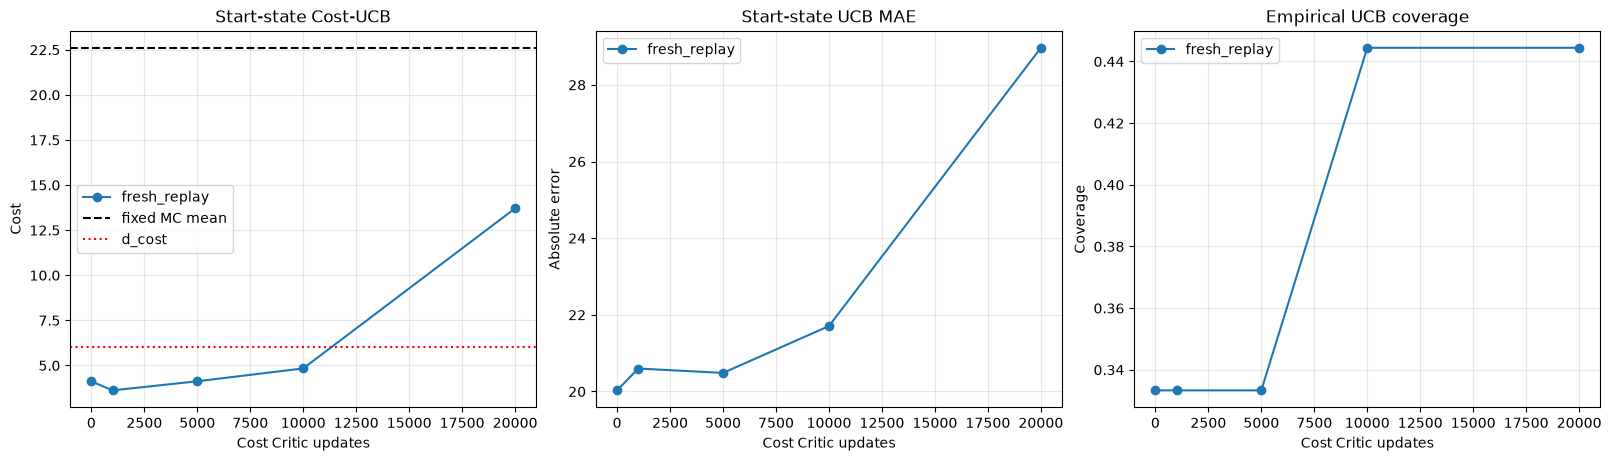

{'fresh_replay': {'count': 27,
  'mc_mean': 22.60962409476045,
  'q_mean': 10.843216940208718,
  'q_ucb_mean': 13.709339486228096,
  'mean_bias': -11.766407154551727,
  'ucb_bias': -8.90028460853235,
  'ucb_mae': 28.96737228293582,
  'ucb_rmse': 37.57586866536185,
  'empirical_ucb_coverage': 0.4444444444444444,
  'branch': 'fresh_replay',
  'updates': 20000,
  'by_n': {'2': {'count': 9,
    'mc_mean': 0.0,
    'q_mean': 13.326451116138035,
    'q_ucb_mean': 19.780780023998684,
    'mean_bias': 13.326451116138035,
    'ucb_bias': 19.780780023998684,
    'ucb_mae': 19.780780023998684,
    'ucb_rmse': 28.645175603098185,
    'empirical_ucb_coverage': 1.0},
   '4': {'count': 9,
    'mc_mean': 46.85968840054867,
    'q_mean': 3.2827963299221463,
    'q_ucb_mean': 3.8785195880466037,
    'mean_bias': -43.57689207062652,
    'ucb_bias': -42.98116881250206,
    'ucb_mae': 42.98116881250206,
    'ucb_rmse': 52.23337861045515,
    'empirical_ucb_coverage': 0.0},
   '8': {'count': 9,
    'mc_mean

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_cost_critic_followup/cost_critic_followup.png
全結果: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_cost_critic_followup


In [9]:
if not all_results:
    raise RuntimeError('RUN_FRESH_REPLAYまたはRUN_OLD_REPLAYをTrueにしてください。')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for branch, result in all_results.items():
    summaries = result[0]
    x = [row['updates'] for row in summaries]
    axes[0].plot(x, [row['q_ucb_mean'] for row in summaries], marker='o', label=branch)
    axes[1].plot(x, [row['ucb_mae'] for row in summaries], marker='o', label=branch)
    axes[2].plot(x, [row['empirical_ucb_coverage'] for row in summaries], marker='o', label=branch)
mc_mean = next(iter(all_results.values()))[0][0]['mc_mean']
axes[0].axhline(mc_mean, color='black', linestyle='--', label='fixed MC mean')
axes[0].axhline(config.learning.d_cost, color='red', linestyle=':', label='d_cost')
for ax, title, ylabel in zip(axes, ('Start-state Cost-UCB', 'Start-state UCB MAE', 'Empirical UCB coverage'), ('Cost', 'Absolute error', 'Coverage')):
    ax.set_title(title); ax.set_xlabel('Cost Critic updates'); ax.set_ylabel(ylabel); ax.grid(alpha=0.3); ax.legend()
figure_path = OUTPUT_RUN / 'cost_critic_followup.png'
fig.savefig(figure_path, dpi=170)
plt.show()

final_summary = {branch: result[0][-1] for branch, result in all_results.items()}
(OUTPUT_RUN / 'followup_final_summary.json').write_text(json.dumps(final_summary, ensure_ascii=False, indent=2), encoding='utf-8')
display(final_summary)
print('Saved:', figure_path)
print('全結果:', OUTPUT_RUN)

## 判定の目安

- **UCBが固定MCへ継続的に接近**: 主因は学習量・1-step TD伝播速度不足
- **freshだけ改善**: 過去方策混在によるoff-policy distribution shiftの影響が大きい
- **5〜8程度で頭打ち**: 単純なepisode不足ではなく、target・表現・discount・終端・action semantics等を監査
- **Cost直前は改善するが151+ step前やStart-stateが低い**: 長期のCost伝播不足が濃厚。次段階でn-step等を検討

この追試中は`d_cost`、Cost定義、1-step TD、ensemble構成を変更しません。